In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
import pandas as pd

# Upload file using GUI
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

print(df.head())
print(df.info())

Saving uk_private_clinic_no_show_2026.csv to uk_private_clinic_no_show_2026.csv
   appointment_id  patient_id  age  gender postcode_area  \
0               1         861   53    Male           B15   
1               2        1295   32    Male          CF10   
2               3        1131   18    Male           BS1   
3               4        1096   43  Female            M1   
4               5        1639   21    Male            G1   

   distance_to_clinic_km clinic_id    clinic_type appointment_type  \
0                    6.2        C1  Physiotherapy      New Patient   
1                    5.9        C3             GP        Follow-up   
2                    3.6        C2  Physiotherapy        Follow-up   
3                    7.5        C4             GP        Follow-up   
4                    5.5        C5    Dermatology      New Patient   

   consultation_fee_gbp  ... days_since_last_visit has_chronic_condition_flag  \
0                    93  ...                   204       

In [10]:
# Convert categorical columns if needed
df = df.dropna()

# Example: Convert Yes/No to 1/0 (modify based on dataset)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

In [11]:
# Assume last column is target (modify if needed)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [14]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.01
epochs = 1000

In [15]:
for i in range(epochs):

    # Linear equation (like PPT: b0 + b1x1 + b2x2 ...)
    linear_model = np.dot(X, weights) + bias

    # Apply sigmoid
    y_pred = sigmoid(linear_model)

    # Compute gradients
    dw = (1 / len(y)) * np.dot(X.T, (y_pred - y))
    db = (1 / len(y)) * np.sum(y_pred - y)

    # Update weights
    weights -= learning_rate * dw
    bias -= learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}")

Epoch 0
Epoch 100
Epoch 200
Epoch 300
Epoch 400
Epoch 500
Epoch 600
Epoch 700
Epoch 800
Epoch 900


In [16]:
def predict(X):
    linear_model = np.dot(X, weights) + bias
    y_prob = sigmoid(linear_model)

    # Decision Rule (from PPT)
    y_class = [1 if i > 0.5 else 0 for i in y_prob]

    return np.array(y_class), y_prob

In [17]:
y_pred_class, y_prob = predict(X)

accuracy = np.mean(y_pred_class == y)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [18]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

loss = binary_cross_entropy(y, y_prob)
print("Loss:", loss)

Loss: 0.08039691865596799


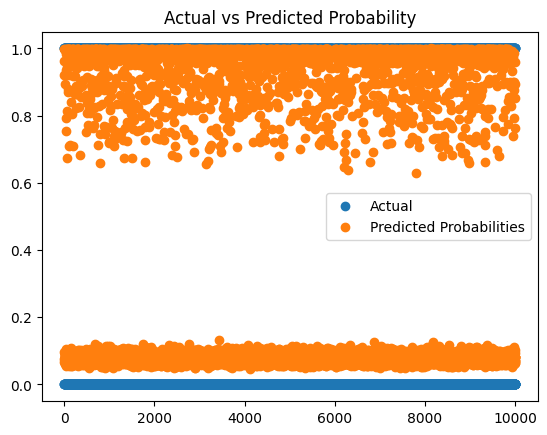

In [19]:
plt.scatter(range(len(y)), y, label="Actual")
plt.scatter(range(len(y_prob)), y_prob, label="Predicted Probabilities")
plt.legend()
plt.title("Actual vs Predicted Probability")
plt.show()